In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Saving Banglore_traffic_Dataset.csv to Banglore_traffic_Dataset.csv
Dataset loaded successfully!
Shape: (8936, 16)

Columns:
['Date', 'Area Name', 'Road/Intersection Name', 'Traffic Volume', 'Average Speed', 'Travel Time Index', 'Congestion Level', 'Road Capacity Utilization', 'Incident Reports', 'Environmental Impact', 'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage', 'Pedestrian and Cyclist Count', 'Weather Conditions', 'Roadwork and Construction Activity']


In [4]:
# Create date-based features

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.day_name()

print("Date features created successfully!")
print(df[["Date", "Year", "Month", "Day", "Day_of_Week"]].head())

Date features created successfully!
        Date  Year  Month  Day Day_of_Week
0 2022-01-01  2022      1    1    Saturday
1 2022-01-01  2022      1    1    Saturday
2 2022-01-01  2022      1    1    Saturday
3 2022-01-01  2022      1    1    Saturday
4 2022-01-01  2022      1    1    Saturday


In [5]:
# Final 15 features used by the model

features = [
    "Area Name",
    "Road/Intersection Name",
    "Traffic Volume",
    "Average Speed",
    "Incident Reports",
    "Public Transport Usage",
    "Traffic Signal Compliance",
    "Parking Usage",
    "Pedestrian and Cyclist Count",
    "Weather Conditions",
    "Roadwork and Construction Activity",
    "Year",
    "Month",
    "Day",
    "Day_of_Week"
]

X_analysis = df[features]
y_actual = df["Congestion Level"]

print("Features created successfully!")
print("Number of features:", len(features))
print("X shape:", X_analysis.shape)
print("y shape:", y_actual.shape)

Features created successfully!
Number of features: 15
X shape: (8936, 15)
y shape: (8936,)


In [6]:
from google.colab import files
import joblib

uploaded_model = files.upload()

model_file = list(uploaded_model.keys())[0]

loaded_model = joblib.load(model_file)

print("Model loaded successfully!")
print("Model type:", type(loaded_model))

Saving bangalore_traffic_final_model.pkl to bangalore_traffic_final_model (1).pkl
Model loaded successfully!
Model type: <class 'sklearn.pipeline.Pipeline'>


In [7]:
print("Pipeline steps:")
print(loaded_model.named_steps)

Pipeline steps:
{'preprocessor': ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Area Name', 'Road/Intersection Name',
                                  'Weather Conditions',
                                  'Roadwork and Construction Activity',
                                  'Day_of_Week']),
                                ('num', StandardScaler(),
                                 ['Traffic Volume', 'Average Speed',
                                  'Incident Reports', 'Public Transport Usage',
                                  'Traffic Signal Compliance', 'Parking Usage',
                                  'Pedestrian and Cyclist Count', 'Year',
                                  'Month', 'Day'])]), 'model': RandomForestRegressor(n_jobs=-1, random_state=42)}


In [8]:
# Extract preprocessor and Random Forest model

preprocessor = loaded_model.named_steps["preprocessor"]
rf_model = loaded_model.named_steps["model"]

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get feature importance
importance = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Important Features:")
print(feature_importance_df.head(20).to_string(index=False))

Top 20 Important Features:
                          Feature  Importance
              num__Traffic Volume    0.970401
               num__Parking Usage    0.003455
               num__Average Speed    0.003296
      num__Public Transport Usage    0.003284
   num__Traffic Signal Compliance    0.003099
num__Pedestrian and Cyclist Count    0.002688
            num__Incident Reports    0.002540
                         num__Day    0.002471
                       num__Month    0.001736
                        num__Year    0.000614
    cat__Weather Conditions_Clear    0.000315
        cat__Day_of_Week_Saturday    0.000288
          cat__Day_of_Week_Sunday    0.000277
        cat__Day_of_Week_Thursday    0.000270
       cat__Day_of_Week_Wednesday    0.000261
 cat__Weather Conditions_Overcast    0.000255
         cat__Day_of_Week_Tuesday    0.000254
          cat__Day_of_Week_Friday    0.000244
          cat__Day_of_Week_Monday    0.000240
     cat__Weather Conditions_Rain    0.000213


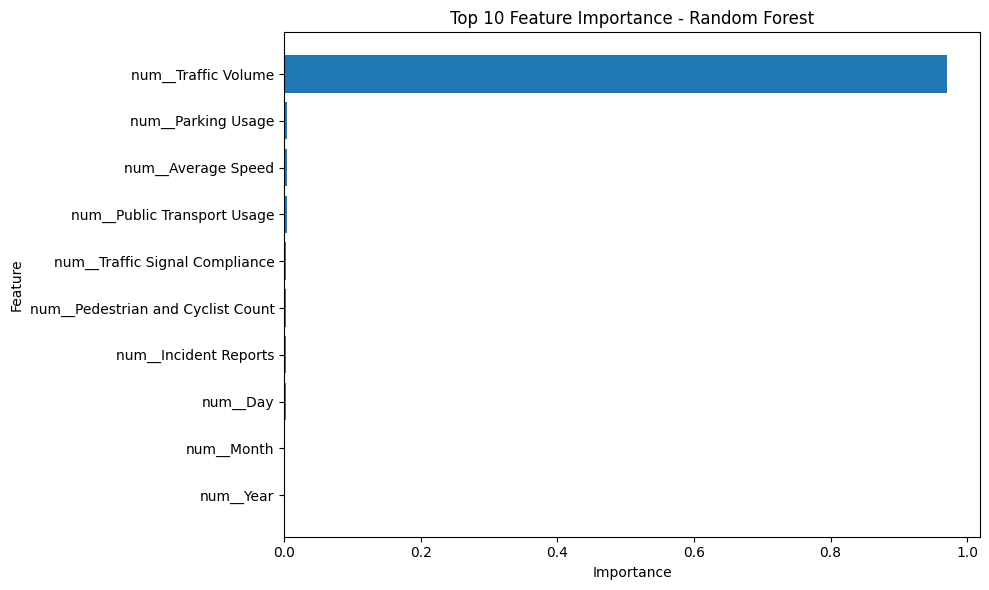

In [9]:
top_features = feature_importance_df.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

In [10]:
# Generate predictions using the loaded final model

y_predicted = loaded_model.predict(X_analysis)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_predicted))

print("\nFirst 10 predictions:")
print(y_predicted[:10])

Predictions generated successfully!
Number of predictions: 8936

First 10 predictions:
[100.          99.45965692  26.58934247 100.         100.
 100.         100.          80.1849664   80.02142823  98.37194324]


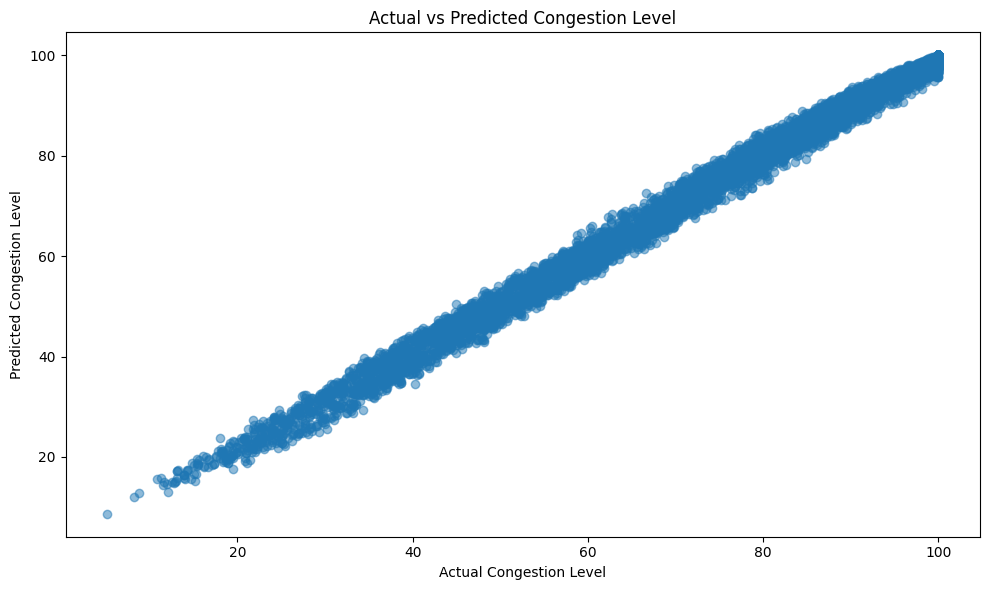

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_actual,
    y_predicted,
    alpha=0.5
)

plt.xlabel("Actual Congestion Level")
plt.ylabel("Predicted Congestion Level")
plt.title("Actual vs Predicted Congestion Level")

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_actual, y_predicted)
rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
r2 = r2_score(y_actual, y_predicted)

print("===== FINAL MODEL PERFORMANCE =====")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

===== FINAL MODEL PERFORMANCE =====
MAE  : 1.0662559408330354
RMSE : 1.63281488384865
R²   : 0.9951853889370059


In [13]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_analysis,
    y_actual,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (7148, 15)
Testing data : (1788, 15)


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

categorical_features = [
    "Area Name",
    "Road/Intersection Name",
    "Weather Conditions",
    "Roadwork and Construction Activity",
    "Day_of_Week"
]

numerical_features = [
    "Traffic Volume",
    "Average Speed",
    "Incident Reports",
    "Public Transport Usage",
    "Traffic Signal Compliance",
    "Parking Usage",
    "Pedestrian and Cyclist Count",
    "Year",
    "Month",
    "Day"
]

validation_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

validation_model = Pipeline(
    steps=[
        ("preprocessor", validation_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

validation_model.fit(X_train, y_train)

print("Validation model trained successfully!")

Validation model trained successfully!


In [15]:
# Predict congestion levels for unseen test data

y_test_predicted = validation_model.predict(X_test)

print("Test predictions generated successfully!")
print("Number of test predictions:", len(y_test_predicted))

print("\nFirst 10 test predictions:")
print(y_test_predicted[:10])

Test predictions generated successfully!
Number of test predictions: 1788

First 10 test predictions:
[100.         100.          76.35914369  77.01937216  57.54367922
  87.87325894  51.89939581  88.42498235  90.3647171  100.        ]


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_mae = mean_absolute_error(y_test, y_test_predicted)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_predicted))
test_r2 = r2_score(y_test, y_test_predicted)

print("===== UNSEEN TEST DATA PERFORMANCE =====")
print("MAE  :", test_mae)
print("RMSE :", test_rmse)
print("R²   :", test_r2)

===== UNSEEN TEST DATA PERFORMANCE =====
MAE  : 2.832494944391957
RMSE : 4.318608170397377
R²   : 0.9655240594455341


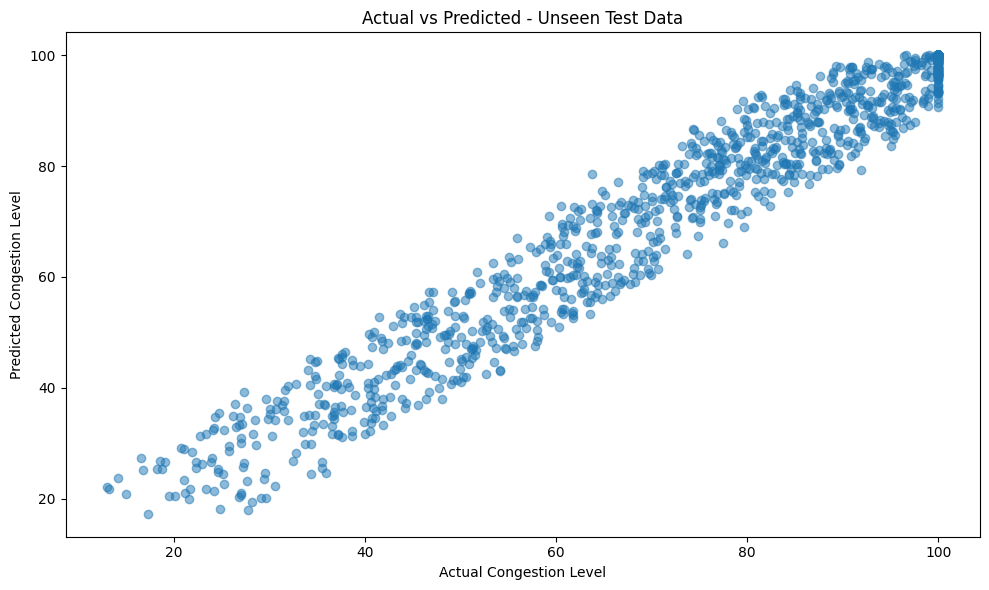

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_test_predicted,
    alpha=0.5
)

plt.xlabel("Actual Congestion Level")
plt.ylabel("Predicted Congestion Level")
plt.title("Actual vs Predicted - Unseen Test Data")

plt.tight_layout()
plt.show()

In [18]:
error = y_test - y_test_predicted

print("Prediction Error Analysis")
print("Mean Error:", error.mean())
print("Minimum Error:", error.min())
print("Maximum Error:", error.max())

Prediction Error Analysis
Mean Error: -0.0887151407127415
Minimum Error: -14.783364234799983
Maximum Error: 12.551526624400012


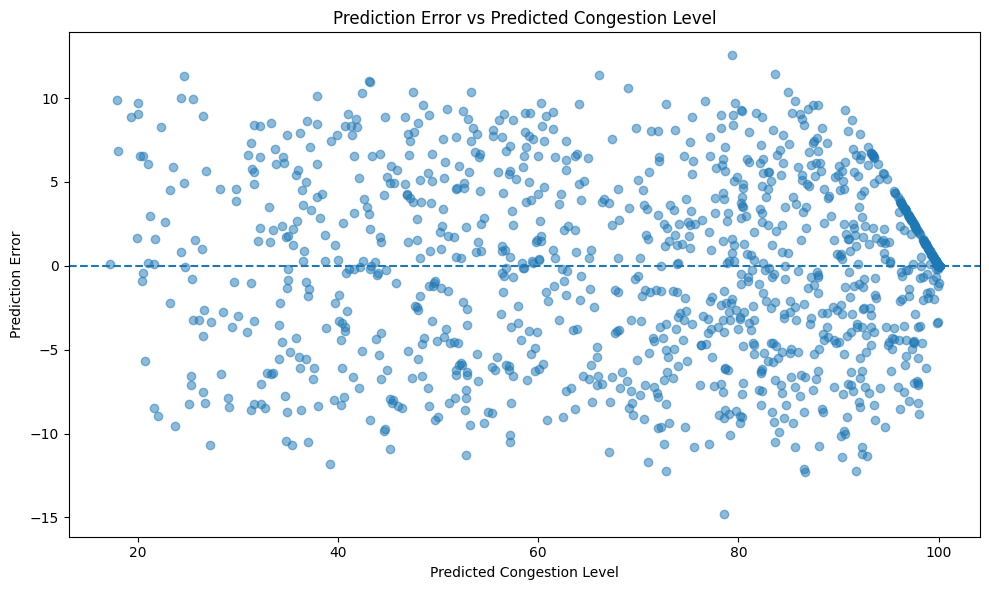

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_predicted,
    error,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Congestion Level")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs Predicted Congestion Level")

plt.tight_layout()
plt.show()

In [20]:
# Create congestion ranges based on actual values

ranges = pd.cut(
    y_test,
    bins=[0, 25, 50, 75, 90, 100],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"],
    include_lowest=True
)

range_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_predicted,
    "Range": ranges.values
})

range_mae = range_results.groupby("Range", observed=False).apply(
    lambda group: mean_absolute_error(
        group["Actual"],
        group["Predicted"]
    )
)

print("===== MAE BY CONGESTION RANGE =====")
print(range_mae)

===== MAE BY CONGESTION RANGE =====
Range
Very Low     5.354156
Low          5.043276
Moderate     5.243190
High         4.623945
Very High    0.948590
dtype: float64


/tmp/ipykernel_1032/3514388829.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  range_mae = range_results.groupby("Range", observed=False).apply(


In [21]:
range_counts = range_results["Range"].value_counts().sort_index()

print("===== TEST RECORDS BY CONGESTION RANGE =====")
print(range_counts)

===== TEST RECORDS BY CONGESTION RANGE =====
Range
Very Low      36
Low          217
Moderate     318
High         260
Very High    957
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    validation_model,
    X_analysis,
    y_actual,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

print("===== 5-FOLD CROSS-VALIDATION =====")
print("R² Scores:")
print(cv_scores)

print("\nMean R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

===== 5-FOLD CROSS-VALIDATION =====
R² Scores:
[0.96544634 0.96630496 0.96602732 0.96542626 0.9656804 ]

Mean R²: 0.9657770569354651
Standard Deviation: 0.0003414915466059362


In [23]:
# Sort dataset chronologically

df_time = df.sort_values("Date").reset_index(drop=True)

unique_dates = df_time["Date"].drop_duplicates().reset_index(drop=True)

print("===== TIME-BASED DATA PREPARATION =====")
print("Total records:", len(df_time))
print("Unique dates:", len(unique_dates))
print("First date:", unique_dates.iloc[0])
print("Last date:", unique_dates.iloc[-1])

===== TIME-BASED DATA PREPARATION =====
Total records: 8936
Unique dates: 952
First date: 2022-01-01 00:00:00
Last date: 2024-08-09 00:00:00


In [24]:
# Split dates chronologically: first 80% for training, last 20% for testing

split_point = int(len(unique_dates) * 0.80)

train_dates = unique_dates.iloc[:split_point]
test_dates = unique_dates.iloc[split_point:]

train_mask = df_time["Date"].isin(train_dates)
test_mask = df_time["Date"].isin(test_dates)

X_train_time = df_time.loc[train_mask, features]
y_train_time = df_time.loc[train_mask, "Congestion Level"]

X_test_time = df_time.loc[test_mask, features]
y_test_time = df_time.loc[test_mask, "Congestion Level"]

print("===== CHRONOLOGICAL TRAIN/TEST SPLIT =====")
print("Training records:", len(X_train_time))
print("Testing records :", len(X_test_time))

print("\nTraining period:")
print(train_dates.iloc[0], "to", train_dates.iloc[-1])

print("\nTesting period:")
print(test_dates.iloc[0], "to", test_dates.iloc[-1])

===== CHRONOLOGICAL TRAIN/TEST SPLIT =====
Training records: 7145
Testing records : 1791

Training period:
2022-01-01 00:00:00 to 2024-01-31 00:00:00

Testing period:
2024-02-01 00:00:00 to 2024-08-09 00:00:00


In [25]:
time_model = Pipeline(
    steps=[
        ("preprocessor", ColumnTransformer(
            transformers=[
                ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
                ("num", StandardScaler(), numerical_features)
            ]
        )),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

time_model.fit(X_train_time, y_train_time)

print("Time-based validation model trained successfully!")

Time-based validation model trained successfully!


In [26]:
# Predict congestion for the future test period

y_pred_time = time_model.predict(X_test_time)

print("===== TIME-BASED PREDICTIONS =====")
print("Number of predictions:", len(y_pred_time))

print("\nFirst 10 predictions:")
print(y_pred_time[:10])

===== TIME-BASED PREDICTIONS =====
Number of predictions: 1791

First 10 predictions:
[ 99.69338126 100.          50.33415948 100.         100.
  95.35683096  34.64101749  88.1825972  100.          90.40306816]


In [27]:
time_mae = mean_absolute_error(y_test_time, y_pred_time)
time_rmse = np.sqrt(mean_squared_error(y_test_time, y_pred_time))
time_r2 = r2_score(y_test_time, y_pred_time)

print("===== TIME-BASED VALIDATION PERFORMANCE =====")
print("MAE  :", time_mae)
print("RMSE :", time_rmse)
print("R²   :", time_r2)

===== TIME-BASED VALIDATION PERFORMANCE =====
MAE  : 2.828947030491725
RMSE : 4.3312048307058095
R²   : 0.9659237458409816


In [28]:
final_results = pd.DataFrame({
    "Validation": [
        "Random 80/20 Test",
        "5-Fold Cross-Validation",
        "Time-Based Test"
    ],
    "MAE": [
        test_mae,
        np.nan,
        time_mae
    ],
    "RMSE": [
        test_rmse,
        np.nan,
        time_rmse
    ],
    "R2": [
        test_r2,
        cv_scores.mean(),
        time_r2
    ]
})

print("===== FINAL MODEL VALIDATION SUMMARY =====")
print(final_results.round(4).to_string(index=False))

===== FINAL MODEL VALIDATION SUMMARY =====
             Validation    MAE   RMSE     R2
      Random 80/20 Test 2.8325 4.3186 0.9655
5-Fold Cross-Validation    NaN    NaN 0.9658
        Time-Based Test 2.8289 4.3312 0.9659


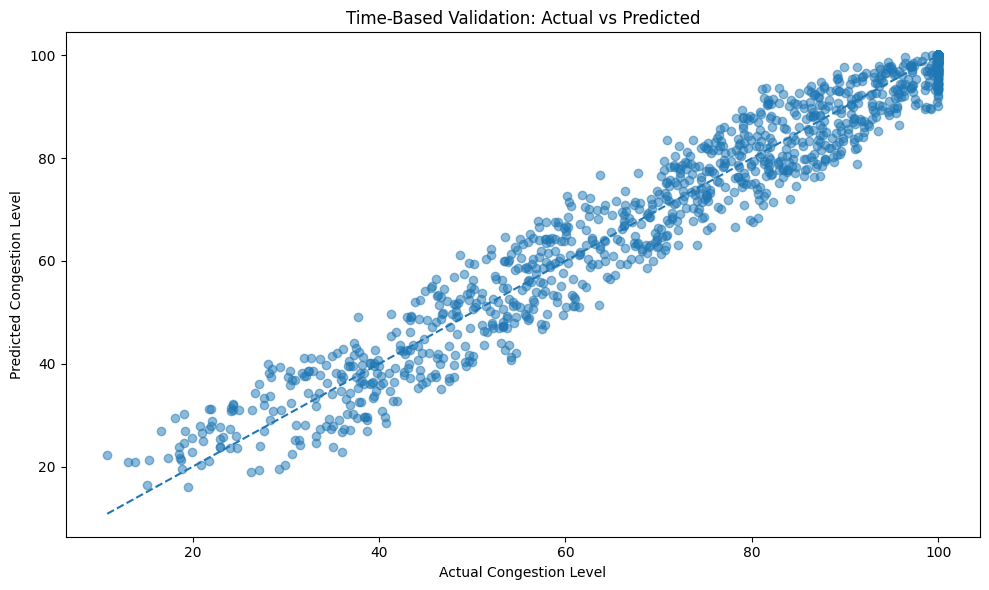

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_time,
    y_pred_time,
    alpha=0.5
)

plt.plot(
    [y_test_time.min(), y_test_time.max()],
    [y_test_time.min(), y_test_time.max()],
    linestyle="--"
)

plt.xlabel("Actual Congestion Level")
plt.ylabel("Predicted Congestion Level")
plt.title("Time-Based Validation: Actual vs Predicted")
plt.tight_layout()
plt.show()

In [30]:
import os

model_path = "bangalore_traffic_final_model.pkl"

if os.path.exists(model_path):
    file_size_mb = os.path.getsize(model_path) / (1024 * 1024)

    print("===== FINAL MODEL FILE =====")
    print("File Name :", model_path)
    print("File Exists : YES")
    print("File Size :", round(file_size_mb, 2), "MB")
else:
    print("File Exists : NO")
    print("Model file not found.")

===== FINAL MODEL FILE =====
File Name : bangalore_traffic_final_model.pkl
File Exists : YES
File Size : 44.97 MB


In [31]:
print("===== FINAL BENGALURU TRAFFIC MODEL =====")

print("Dataset Records :", len(df))
print("Number of Features :", len(features))
print("Model :", "Random Forest Regressor")
print("Number of Trees :", rf_model.n_estimators)

print("\n----- Random 80/20 Test -----")
print("MAE  :", round(test_mae, 4))
print("RMSE :", round(test_rmse, 4))
print("R²   :", round(test_r2, 4))

print("\n----- 5-Fold Cross-Validation -----")
print("Mean R² :", round(cv_scores.mean(), 4))
print("Std R²  :", round(cv_scores.std(), 6))

print("\n----- Time-Based Test -----")
print("MAE  :", round(time_mae, 4))
print("RMSE :", round(time_rmse, 4))
print("R²   :", round(time_r2, 4))

print("\nModel File : bangalore_traffic_final_model.pkl")

===== FINAL BENGALURU TRAFFIC MODEL =====
Dataset Records : 8936
Number of Features : 15
Model : Random Forest Regressor
Number of Trees : 100

----- Random 80/20 Test -----
MAE  : 2.8325
RMSE : 4.3186
R²   : 0.9655

----- 5-Fold Cross-Validation -----
Mean R² : 0.9658
Std R²  : 0.000341

----- Time-Based Test -----
MAE  : 2.8289
RMSE : 4.3312
R²   : 0.9659

Model File : bangalore_traffic_final_model.pkl
